In [1]:
import pandas as pd

world = pd.read_csv(f'Dados/ComtradeData2.csv', sep=',', encoding='latin')

In [2]:

exp_1 = pd.read_csv(f'derived/exp_2.csv', sep=',')

In [3]:
print(world.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='str')


In [4]:
print(exp_1.head())

       Country                                               Info  Month  \
0  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      3   
1  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      4   
2  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      5   
3  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      5   
4  Afghanistan  Caixas, sacos, bolsas, cartuchos e outras emba...      6   

   Year  Value Code  
0  2022     61  AFG  
1  2021      7  AFG  
2  2020     41  AFG  
3  2024     40  AFG  
4  2019     41  AFG  


In [5]:
import pandas as pd

# Assumindo que o seu DataFrame se chama 'world' (como na imagem)
# O código abaixo é um exemplo de como faria o cálculo.

def calcular_market_share(df, produto_capitulo='47', metrica='primaryValue'):
    """
    Calcula o market share do Brasil em relação ao Mundo por ANO.
    
    Parâmetros:
    df: o DataFrame do Comtrade.
    produto_capitulo: '47' para Celulose, '48' para Papel.
    metrica: 'primaryValue' para Dólares, 'netWgt' para volume (Kg).
    """
    
    # 1. Filtrar apenas as EXPORTAÇÕES do capítulo desejado
    df_filtrado = df[
        (df['ncmCode'] == produto_capitulo) & 
        (df['flowDesc'].astype(str).str.contains('Export', case=False, na=False))
    ].copy()
    
    # Garantir que a coluna da métrica é numérica
    df_filtrado[metrica] = pd.to_numeric(df_filtrado[metrica], errors='coerce')
    
    # 2. Agrupar e Calcular o Total Global (Mundo) por Ano
    global_por_ano = df_filtrado.groupby('refYear')[metrica].sum()
    
    # 3. Agrupar e Calcular o Total do Brasil por Ano
    df_brasil = df_filtrado[df_filtrado['reporterCode'] == 'BRA']
    brasil_por_ano = df_brasil.groupby('refYear')[metrica].sum()
    
    # 4. Juntar os dados em um novo DataFrame
    resultados = pd.DataFrame({
        'Mundo': global_por_ano,
        'Brasil': brasil_por_ano
    }).fillna(0) # Preenche com 0 caso o Brasil não tenha exportado num ano específico
    
    # 5. Calcular a percentagem (Market Share) por ano
    resultados['Market_Share_%'] = (resultados['Brasil'] / resultados['Mundo']) * 100
    resultados['Market_Share_%'] = resultados['Market_Share_%'].fillna(0) # Trata divisões por zero
    
    print(f"--- Análise Anual do Capítulo {produto_capitulo} ({metrica}) ---")
    print(resultados)
    print("\n")
    
    return resultados

# Exemplos de uso:
# Retorna um DataFrame com a evolução anual:
# df_share_celulose = calcular_market_share(world, produto_capitulo='47', metrica='primaryValue')

# Para plotar facilmente depois:
# df_share_celulose['Market_Share_%'].plot(kind='bar', title='Market Share do Brasil - Celulose')

In [6]:
# print(world['flowCode'].unique)
# print(world['isOriginalClassification'].unique)
# print(world['fobvalue'].unique)
# print(world['refPeriodId'].unique)
print(world['reporterCode'].unique())
share_volume_papel = calcular_market_share(world, produto_capitulo='47', metrica='primaryValue')

<StringArray>
['ALB']
Length: 1, dtype: str


KeyError: 'ncmCode'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assumindo que o seu DataFrame se chama 'world' (como na imagem)
# O código abaixo é um exemplo de como faria o cálculo.
def calcular_market_share(df, produto_capitulo='47', metrica='primaryValue', top_n=5):
    """
    Calcula o market share dos maiores exportadores em relação ao Mundo por ANO.
    
    Parâmetros:
    df: o DataFrame do Comtrade.
    produto_capitulo: '47' para Celulose, '48' para Papel.
    metrica: 'primaryValue' para Dólares, 'netWgt' para volume (Kg).
    top_n: Quantidade de maiores exportadores (padrão: 5).
    """
    
    # 1. Filtrar apenas as EXPORTAÇÕES do capítulo desejado
    df_filtrado = df[
        (df['isOriginalClassification'] == produto_capitulo) & 
        (df['flowCode'].astype(str).str.contains('Export', case=False, na=False))
    ].copy()
    
    # Garantir que a coluna da métrica é numérica
    df_filtrado[metrica] = pd.to_numeric(df_filtrado[metrica], errors='coerce')
    
    # 2. Agrupar e Calcular o Total Global (Mundo) por Ano
    global_por_ano = df_filtrado.groupby('refPeriodId')[metrica].sum()
    
    # 3. Identificar os TOP N maiores exportadores de todo o período
    total_por_pais = df_filtrado.groupby('reporterCode')[metrica].sum()
    maiores_exportadores = total_por_pais.nlargest(top_n).index
    
    # 4. Filtrar os dados apenas para os maiores exportadores e agrupar por ano
    df_top = df_filtrado[df_filtrado['reporterCode'].isin(maiores_exportadores)]
    paises_por_ano = df_top.groupby(['refPeriodId', 'reporterCode'])[metrica].sum().unstack(fill_value=0)
    
    # 5. Calcular a percentagem (Market Share) por ano para cada país
    market_share_df = paises_por_ano.div(global_por_ano, axis=0) * 100
    market_share_df = market_share_df.fillna(0) # Trata divisões por zero
    
    print(f"--- Análise Anual do Capítulo {produto_capitulo} ({metrica}) - Top {top_n} ---")
    print(market_share_df)
    print("\n")
    
    # 6. Plotar a evolução
    plt.figure(figsize=(12, 6))
    for pais in market_share_df.columns:
        plt.plot(market_share_df.index.astype(str), market_share_df[pais], marker='o', linewidth=2, label=pais)
        
    plt.title(f'Evolução do Market Share: Top {top_n} Exportadores - Cap {produto_capitulo}', fontsize=16)
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel(f'Market Share (%)', fontsize=12)
    plt.legend(title='Código do País', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return market_share_df

# Exemplos de uso:
# Retorna o DataFrame com a evolução anual dos top 5 exportadores e já exibe o gráfico:
# df_share_celulose = calcular_market_share(world, produto_capitulo='47', metrica='fobvalue', top_n=5)

--- Análise Anual do Capítulo 47 (fobvalue) - Top 5 ---
reporterCode    ALB
refPeriodId        
2016          100.0
2017          100.0
2018          100.0
2019          100.0
2020          100.0
2021          100.0
2022          100.0
2023          100.0
2024          100.0




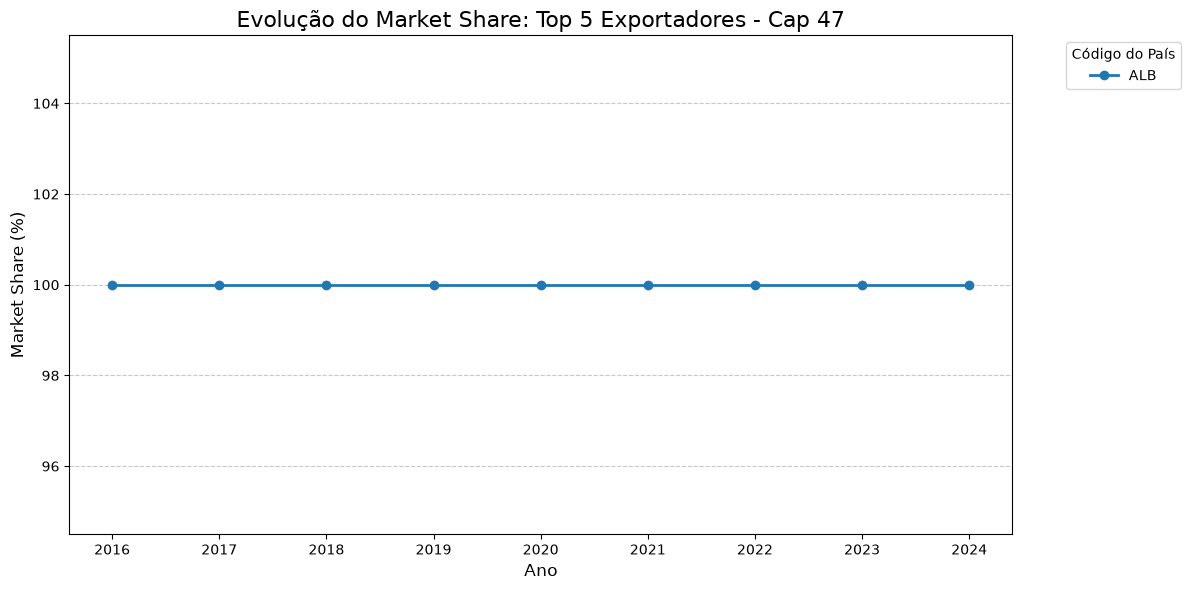

In [ ]:
result = calcular_market_share(world, produto_capitulo='47', metrica='fobvalue', top_n=5)

--- Análise Anual do Capítulo 47 (fobvalue) - Top 10 ---
reporterCode    ALB
refPeriodId        
2016          100.0
2017          100.0
2018          100.0
2019          100.0
2020          100.0
2021          100.0
2022          100.0
2023          100.0
2024          100.0




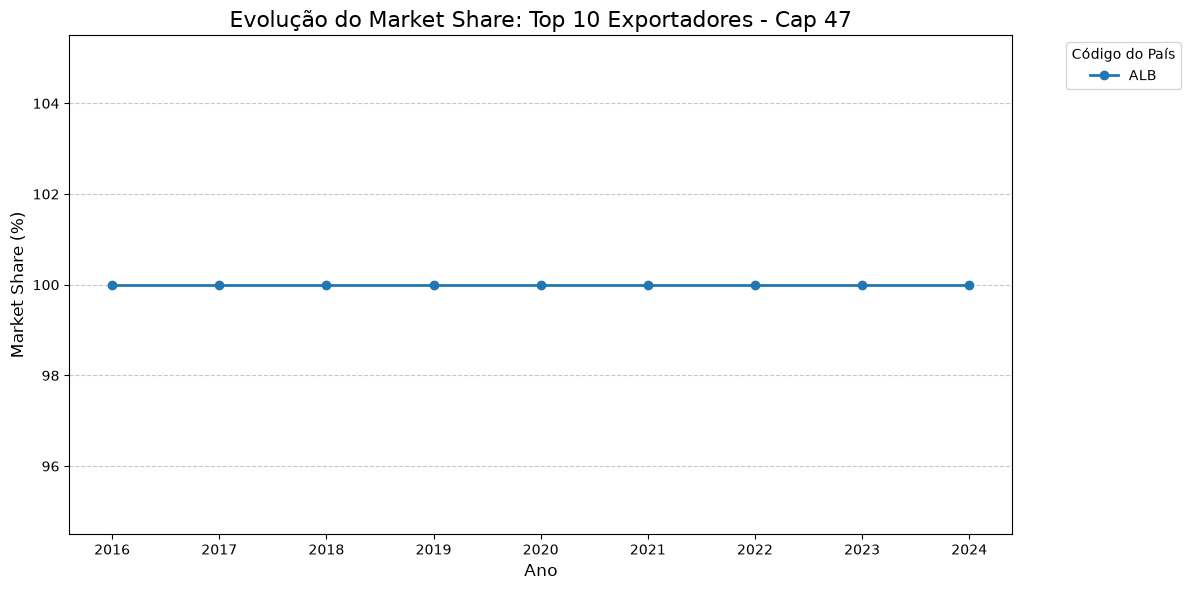

In [ ]:
result = calcular_market_share(world, produto_capitulo='47', metrica='fobvalue', top_n=10)

--- Análise Anual do Capítulo 48 (fobvalue) - Top 5 ---
reporterCode    ALB
refPeriodId        
2016          100.0
2017          100.0
2018          100.0
2019          100.0
2020          100.0
2021          100.0
2022          100.0
2023          100.0
2024          100.0




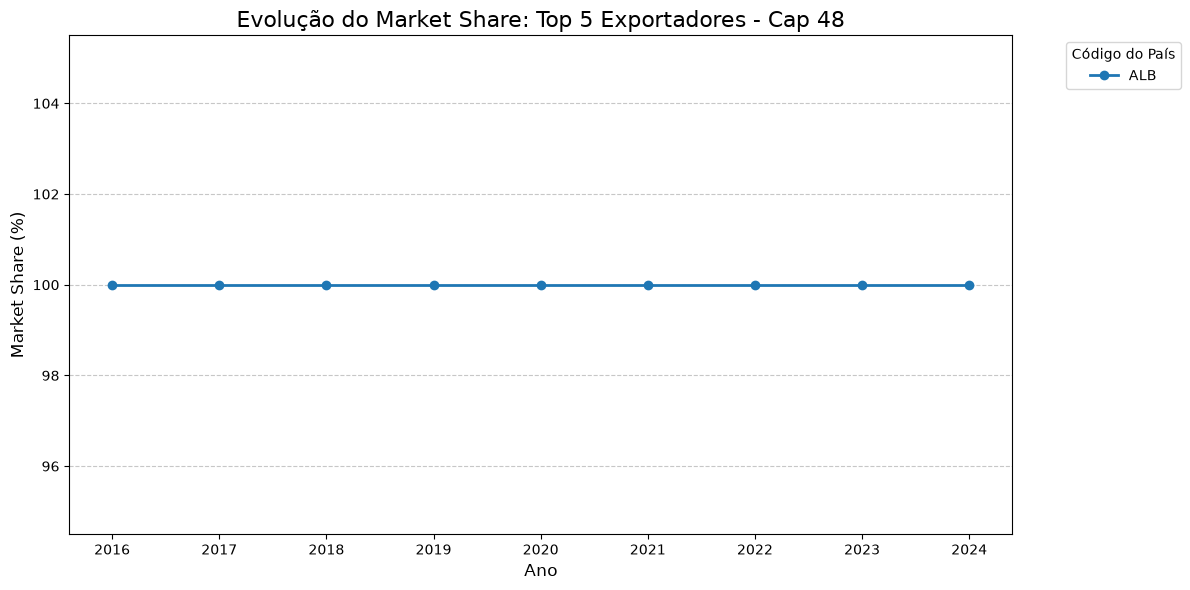

In [ ]:
result = calcular_market_share(world, produto_capitulo='48', metrica='fobvalue', top_n=5)

--- Análise Anual do Capítulo 49 (fobvalue) - Top 5 ---
reporterCode    ALB
refPeriodId        
2016          100.0
2017          100.0
2018          100.0
2019          100.0
2020          100.0
2021          100.0
2022          100.0
2023          100.0
2024          100.0




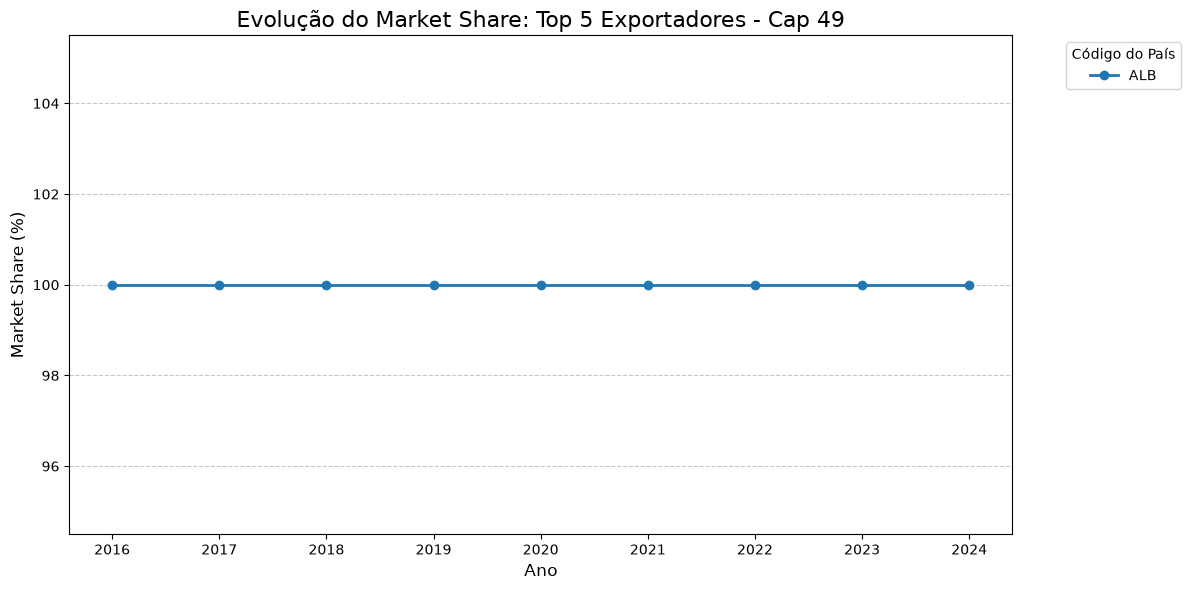

In [ ]:
result = calcular_market_share(world, produto_capitulo='49', metrica='fobvalue', top_n=5)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def principais_compradores_brasil(df, produto_capitulo='47', metrica='primaryValue', top_n=5):
    """
    Identifica os principais países compradores das exportações brasileiras por ano.
    
    Parâmetros:
    df: o DataFrame do Comtrade.
    produto_capitulo: '47' para Celulose, '48' para Papel.
    metrica: 'primaryValue' para Dólares, 'netWgt' para volume (Kg), 'fobvalue', etc.
    top_n: Quantidade de maiores compradores a exibir (padrão: 5).
    """
    
    # 1. Filtrar Exportações do Capítulo específico onde o Brasil é o Vendedor (Reporter)
    # Tenta usar reporterISO ou reporterCode dependendo de como está preenchido
    df_br = df[
        (df['cmdCode'] == produto_capitulo) & 
        (df['flowDesc'].astype(str).str.contains('Export', case=False, na=False)) &
        ((df['reporterISO'] == 'BRA') | (df['reporterCode'] == 'BRA') | (df['reporterCode'] == '76'))
    ].copy()
    
    # Garantir que a métrica é numérica
    df_br[metrica] = pd.to_numeric(df_br[metrica], errors='coerce')
    
    # 2. Excluir o agregado "World" (Mundo) para não distorcer o Top 5 com o total global
    df_br = df_br[~df_br['partnerDesc'].astype(str).str.contains('World', case=False, na=False)]
    df_br = df_br[df_br['partnerDesc'] != '0'] # Algumas vezes o Mundo é o código 0
    
    # 3. Identificar os TOP N maiores compradores durante todo o período
    total_por_comprador = df_br.groupby('partnerDesc')[metrica].sum()
    maiores_compradores = total_por_comprador.nlargest(top_n).index
    
    # 4. Filtrar apenas os dados dos maiores compradores e organizar por Ano
    df_top = df_br[df_br['partnerDesc'].isin(maiores_compradores)]
    evolucao_compradores = df_top.groupby(['refPeriodId', 'partnerDesc'])[metrica].sum().unstack(fill_value=0)
    
    print(f"--- Top {top_n} Compradores do Brasil - Cap {produto_capitulo} ({metrica}) ---")
    print(evolucao_compradores)
    print("\n")
    
    # 5. Plotar a evolução
    plt.figure(figsize=(12, 6))
    for pais in evolucao_compradores.columns:
        # Dividindo por 1 bilhão para o eixo Y ficar mais fácil de ler (se for valor financeiro grande)
        # Se for volume (netWgt), você pode querer ajustar o divisor para milhões (1e6)
        divisor = 1e9 if 'value' in metrica.lower() else 1
        unidade = 'Bilhões de US$' if 'value' in metrica.lower() else metrica
        
        plt.plot(evolucao_compradores.index.astype(str), 
                 evolucao_compradores[pais] / divisor, 
                 marker='o', linewidth=2, label=pais)
        
    plt.title(f'Evolução das Exportações do Brasil por Destino (Top {top_n}) - Cap {produto_capitulo}', fontsize=16)
    plt.xlabel('Ano (refPeriodId)', fontsize=12)
    plt.ylabel(f'Volume/Valor ({unidade})', fontsize=12)
    
    plt.legend(title='País Destino', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return evolucao_compradores

# Exemplo de uso:
# df_compradores_celulose = principais_compradores_brasil(world, produto_capitulo='47', metrica='fobvalue', top_n=5)

--- Top 5 Compradores do Brasil - Cap 47 (fobvalue) ---
Empty DataFrame
Columns: []
Index: []




UnboundLocalError: cannot access local variable 'unidade' where it is not associated with a value

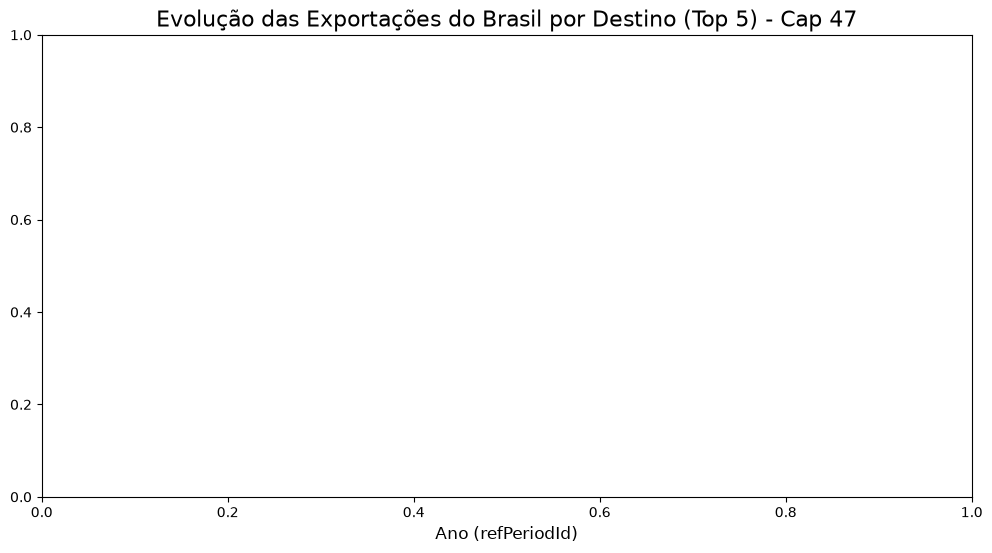

In [ ]:
df_compradores_celulose = principais_compradores_brasil(world, produto_capitulo='47', metrica='fobvalue', top_n=5)